In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pickle
import sys

repo_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/"
sys.path.append(repo_path)

import thesis.code.online_quality_and_celltype.utils as ut

In [3]:
from thesis.code.plot import plot as plotter

plotter.set_default_params(kind='paper')

# load data

In [4]:
data_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype"


data_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype"

# Load quality, traces, celltypes and online2offline mapping
with open(os.path.join(data_dir, "quality_df.pkl"), "rb") as f:
    quality_df = pickle.load(f)

with open(os.path.join(data_dir, "traces_df.pkl"), "rb") as f:
    traces_df = pickle.load(f)

with open(os.path.join(data_dir, "celltypes_df.pkl"), "rb") as f:
    celltypes_df = pickle.load(f)

with open(os.path.join(data_dir, "online2offline_celltype_df.pkl"), "rb") as f:
    online2offline_celltype_df = pickle.load(f)
with open(os.path.join(data_dir, "offline2online_celltype_df.pkl"), "rb") as f:
    offline2online_celltype_df = pickle.load(f)

with open(os.path.join(data_dir, "all_roi_masks.pkl"), "rb") as f:
    all_roi_masks = pickle.load(f)

# Print shapes to verify loading
print(f"Quality dataframe: {quality_df.shape}")
print(f"Traces dataframe: {traces_df.shape}")
print(f"Cell types dataframe: {celltypes_df.shape}")
print(f"Online to offline mapping: {online2offline_celltype_df.shape}")
print(f"Offline to online mapping: {offline2online_celltype_df.shape}")
print(f"ROI masks: {all_roi_masks.shape}")



Quality dataframe: (3873, 15)
Traces dataframe: (7748, 18)
Cell types dataframe: (3873, 18)
Online to offline mapping: (1849, 11)
Offline to online mapping: (2024, 11)
ROI masks: (40, 11)


# Simulation calculation

In [5]:
sim_save_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/online_quality_and_celltype"

In [9]:
from thesis.code.online_quality_and_celltype.simulation import wrapper_sim,get_all_sim_data


# get sim data
C, prob_types = get_all_sim_data(offline2online_celltype_df)

results = wrapper_sim(target=list(range(32)), C=C, prob_type=prob_types,)
results.head()
print(f"Median percentage gain: {results['percentage_gain'].median():.2f}%")

Median percentage gain: 12.03%


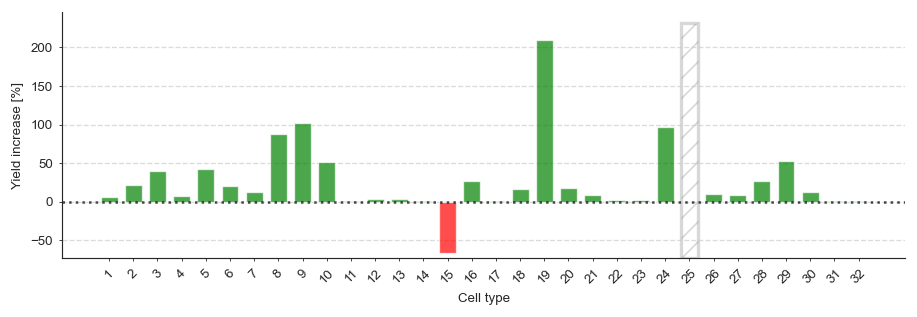

In [70]:
fig,ax = ut.plot_percentage_gain(results,
                                 subplots_kws = {'figsize': plotter.figsize_from_frac(1,1/3)},
                                plt_kws = {},
                                open_bar_celltypes = [25]
)

plotter.tight_layout()

# save
fig.savefig(os.path.join(sim_save_path, "percentage_gain_online_vs_offline_celltype.svg"))


# figures

## quality

In [11]:
quality_pivot = ut.apply_func_and_pivot(quality_df,func=ut.frac_passing_or)




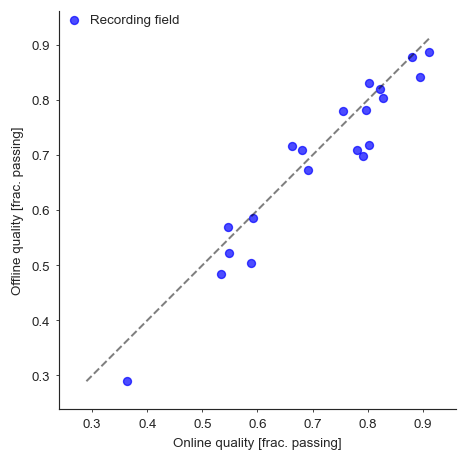

In [23]:
fig,ax = ut.plot_quality_scatter(quality_pivot,
                                 subplot_kws = {'figsize': plotter.figsize_from_frac(0.5,0.5)},
    scatter_kws = {'color':'blue'},
)
plotter.tight_layout()

ax.set_xlabel("Online quality [frac. passing]")
ax.set_ylabel("Offline quality [frac. passing]")

# save
fig.savefig(os.path.join(sim_save_path, "quality_offline_vs_online_scatter_frac_passing.svg"))

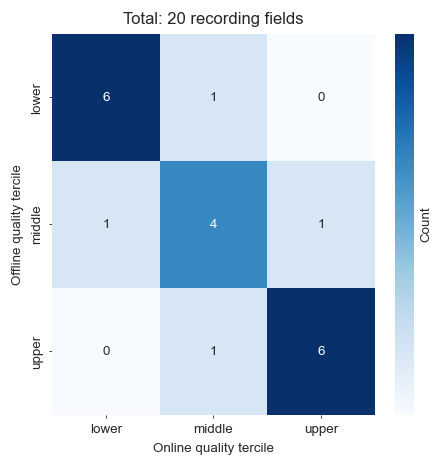

In [31]:
fig,ax =ut.plot_ballpark_quality_contingency(quality_pivot,
                                             subplot_kws = {'figsize': plotter.figsize_from_frac(0.5,0.5)},
                                         heatmap_kws = {},
)
plotter.tight_layout()

# save
fig.savefig(os.path.join(sim_save_path, "quality_offline_online_contingengy_table_frac_passing.svg"))

## Celltype

In [14]:
ct_save_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/online_quality_and_celltype"

### contingcy table and conditional probability table heatplot

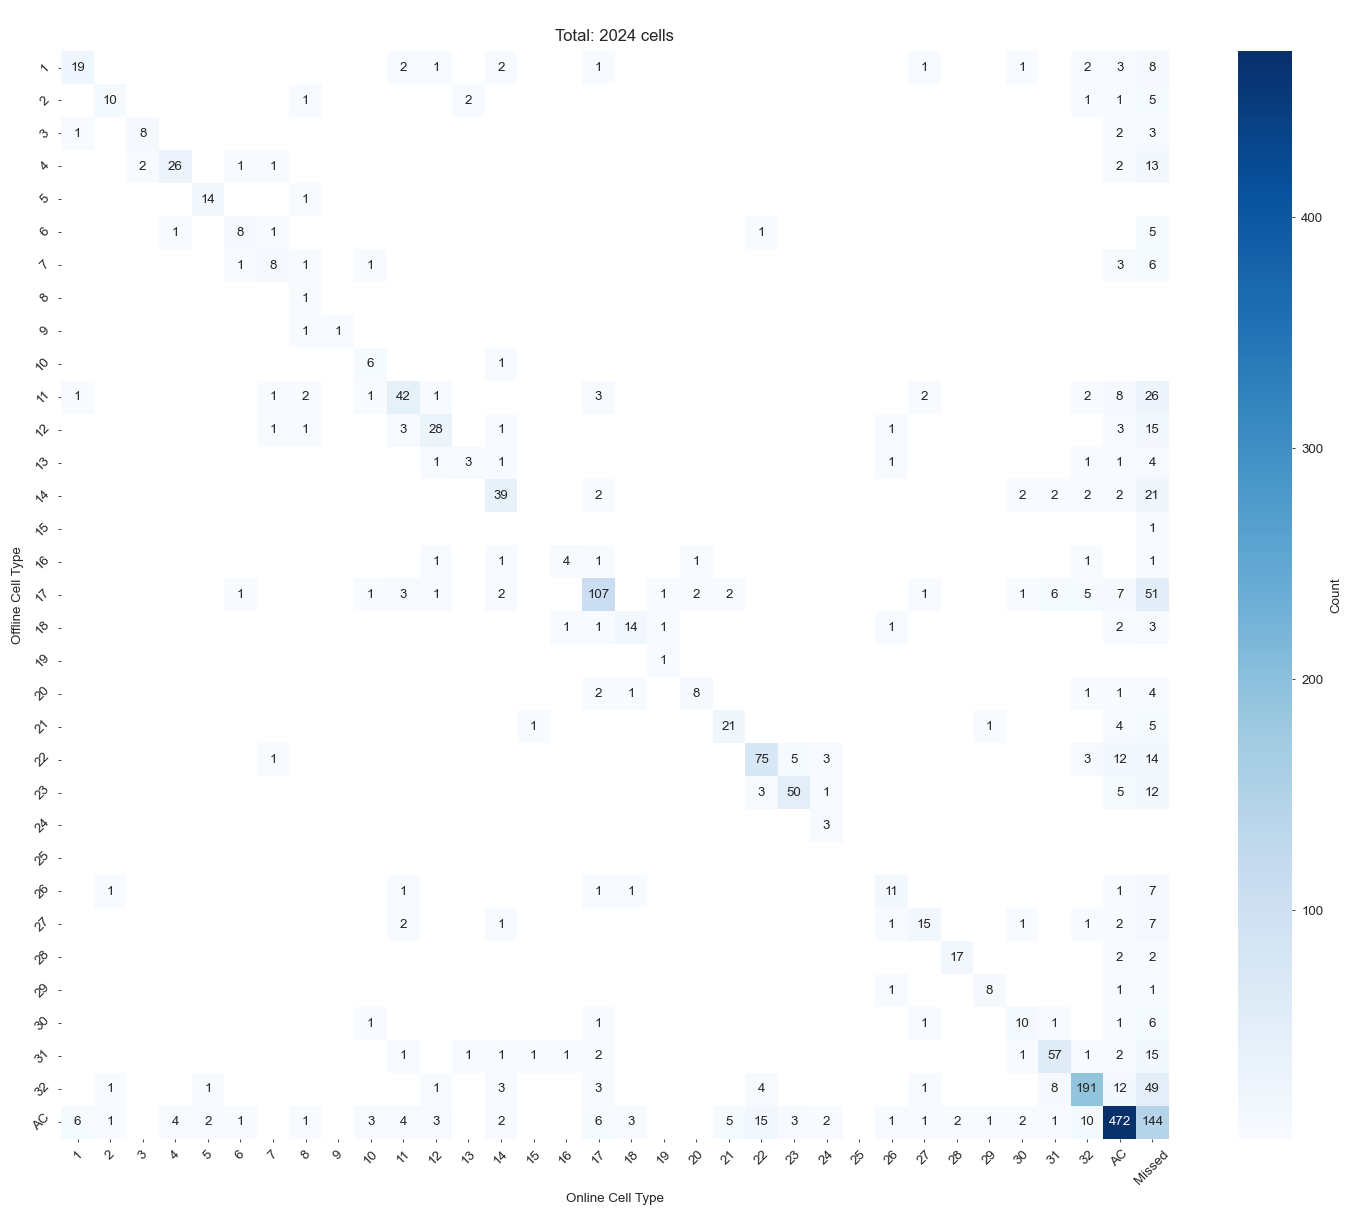

In [15]:
fig,ax = ut.plot_celltype_confusion_matrix(
    df=offline2online_celltype_df,
    offline_col='offline_cell_type',
    online_col='online_cell_type',
    max_type=32,
    figsize=(12,10),
    nan_strategy='group',
    )#heatmap_kws={'vmin':0,'vmax':400})

plotter.tight_layout()

# save
fig.savefig(os.path.join(ct_save_dir, "offline2online_celltype_confusion_matrix_count.svg"))

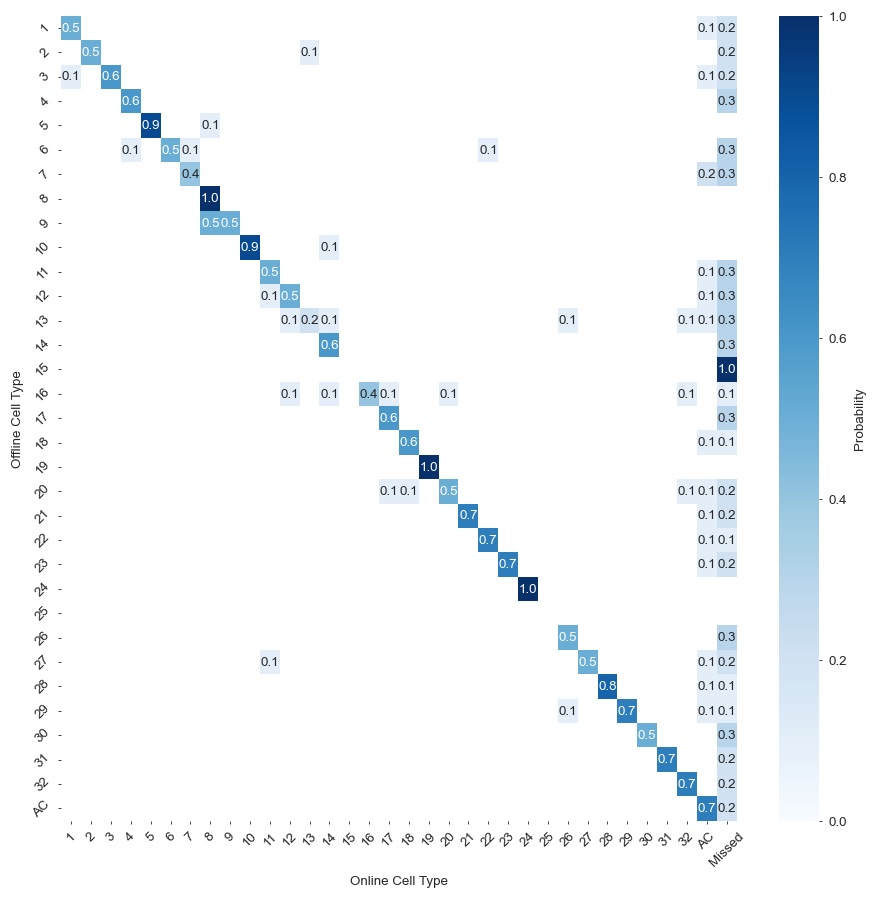

In [ ]:
fig,ax = ut.plot_celltype_confusion_matrix(
    df=offline2online_celltype_df,
    offline_col='offline_cell_type',
    online_col='online_cell_type',
    max_type=32,
    figsize=plotter.figsize_from_frac(1,1),
    plot_counts=False,
    annot_fmt='.1f',
    round_to=1,
    nan_strategy='group',
    heatmap_kws={'vmin':0.0,'vmax':1})

# # Fix the annotations after creating the heatmap
# for text in ax.texts:
#     current_text = text.get_text()
#     if current_text.startswith('0.'):
#         if current_text != '0.0':
#             text.set_text(current_text.replace('0.', '.'))
#         else:
#             text.remove()

plotter.tight_layout()
ax.set_title("")
# save
fig.savefig(os.path.join(ct_save_dir, "offline2online_celltype_confusion_matrix_probability.svg"))